In [1]:
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import pandas as pd

import tqdm

import sys
import os



### First part: Convergence without spinnaker library

In [2]:

#########################################################
################@Copyright from sandilabs################
#########################################################
def generate_gamma_sparse(n_sys, neurons_per_mesh_point, gamma_norm):   
    '''
    Generates the Gamma matrix mapping neurons to readout variables.  
    n_sys: number of readout variables
    neurons_per_mesh_point: number of neurons to place at each mesh node
    gamma_norm:  Magnitude of the readout kernel for each neuron
    
    '''
    
    n_neurons = neurons_per_mesh_point * n_sys

    gamma_data = []
    gamma_row = []
    gamma_col = []
    for pt in range(n_sys):
      
        start_idx = pt * neurons_per_mesh_point
        half_npm = neurons_per_mesh_point//2
        
        gamma_row.extend(neurons_per_mesh_point*[pt])
        gamma_col.extend(list(range(start_idx, start_idx + neurons_per_mesh_point)))
        gamma_data.extend(half_npm*[-gamma_norm])
        gamma_data.extend(half_npm*[gamma_norm])
         
    return sp.sparse.csr_array((np.array(gamma_data), (np.array(gamma_row), np.array(gamma_col))), shape=(n_sys, n_neurons))

#########################################################
################@Copyright from sandilabs################
#########################################################
def create_spiking_fem_network_sparse(A_sys, gamma, gamma_norm, lambda_d=10, lambda_v=20, mu=1e-6, nu=1e-5, tau_A=0.1):
    '''
    Generates sparse weight matrices, thresholds, and reset voltages for a NeuroFEM network implementing the
    linear system A_sys with readout kernel gamma
    '''
    n_sys, n_neurons = gamma.shape
    gTg = (gamma.T) @ gamma
    omega_f = gTg + mu*(lambda_d**2) * sp.sparse.eye_array(n_neurons)
    
    GTAG = (gamma.T) @ (A_sys / tau_A) @ gamma  # should be sparse
    
    threshs = 0.5 * (nu*lambda_d**2 + (gamma_norm**2) * np.ones(n_neurons))
    v_reset = threshs - (gamma_norm**2 + mu*(lambda_d**2)) * np.ones(n_neurons)
    omega_f = omega_f - (gamma_norm**2 + mu*(lambda_d**2)) * sp.sparse.eye_array(n_neurons)

    return omega_f, GTAG, threshs, v_reset



def read_csr_matrx(mtx_filename):
    try:
    
        raw_data = np.loadtxt(mtx_filename, skiprows=1, dtype=float)
        
        
        with open(mtx_filename, 'r') as f:
            header = f.readline().split()
            n_rows = int(header[0])
            n_cols = int(header[1])


        rows = raw_data[:, 0].astype(int) - 1
        cols = raw_data[:, 1].astype(int) - 1
        values = raw_data[:, 2]


        A = sp.sparse.csr_matrix((values, (rows, cols)), shape=(n_rows, n_cols))


        initial_nnz = A.nnz
        A.eliminate_zeros()
        print(f"Shape: {A.shape}")
        print(f"Non-zeros: {A.nnz}")

        return A
    except Exception as e:
        print(f"Failed to load matrix: {e}")
        sys.exit(1)



def read_vec(filename):
    try:
        b = np.loadtxt(filename, dtype=float, skiprows=1)
        return b
    except Exception as e:
        print(f"Failed to load RHS: {e}")
        sys.exit(1)

In [3]:
problem_name = "Sphere_00"
    
mtx_filename = f"{problem_name}_mtx.txt"
rhs_filename = f"{problem_name}_rhs.txt"
sol_filename = f"{problem_name}_sol.txt"

data_directory = "data/matrix/"

print(os.getcwd())

A = read_csr_matrx(data_directory + mtx_filename)
b = read_vec(data_directory + rhs_filename)
x_sol = read_vec("data/solution/" + sol_filename)

x_analytical = read_vec("data/solution/" + "Sphere_00_analytical_rhs.txt")



/home/amirbouslama/Documents/Studium/Neuromorphic-Lab-TUM/NeuromorphicSolver
Shape: (41, 41)
Non-zeros: 403


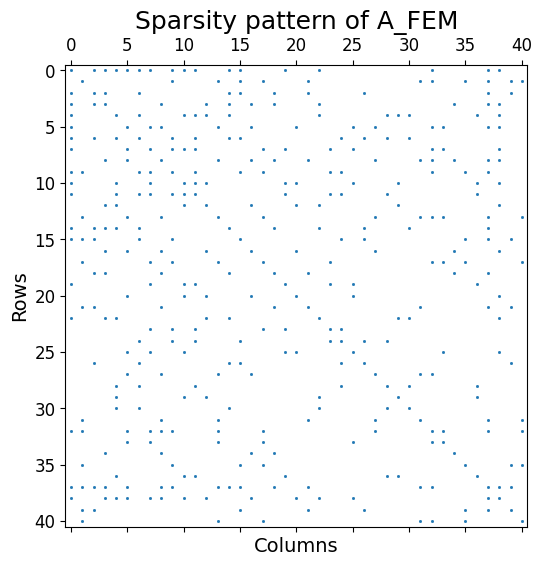

In [4]:
font_size=14
plt.figure(figsize=(6, 6))
plt.spy(A, markersize=1)
plt.title("Sparsity pattern of A_FEM", fontsize=font_size + 4)
plt.xlabel("Columns", fontsize=font_size)
plt.ylabel("Rows", fontsize=font_size)
plt.xticks(fontsize=font_size - 2)
plt.yticks(fontsize=font_size - 2)
plt.show()

In [ ]:
import scipy as sp
import scipy.sparse
import scipy.sparse.linalg
import numpy as np
import sys
import os
import matplotlib.pyplot as plt

# spinnaker2 imports
from spinnaker2 import snn, hardware
from spinnaker2.experiment_backends import BackendSettings
from spinnaker2.experiment_backends.backend_settings import ROUTING

try:
    from brian2 import *
    # [CRITICAL] Force 1ms timestep to match discrete equation logic
    # This prevents the "factor of 10" integration error
    defaultclock.dt = 1*ms
    prefs.codegen.target = 'numpy' 
    HAS_BRIAN2 = True
except ImportError:
    HAS_BRIAN2 = False

# ==========================================
# 1. ROBUST DATA LOADING
# ==========================================
def LoadCSRMatrix(model_name=""):
    mtx_file = f"data/matrix/{model_name}_mtx.txt"
    rhs_file = f"data/matrix/{model_name}_rhs.txt"

    if not os.path.exists(mtx_file):
        print(f"Error: {mtx_file} not found.")
        sys.exit(1)

    raw = np.loadtxt(mtx_file, skiprows=1, dtype=float)
    with open(mtx_file, 'r') as f:
        head = f.readline().split()
        n_rows, n_cols = int(head[0]), int(head[1])
    
    rows = raw[:, 0].astype(int) - 1
    cols = raw[:, 1].astype(int) - 1
    vals = raw[:, 2]
    A_csr = sp.sparse.csr_matrix((vals, (rows, cols)), shape=(n_rows, n_cols))
    
    # Symmetrize if needed
    if (A_csr - A_csr.T).nnz > 0:
        if np.abs(A_csr - A_csr.T).max() > 1e-10:
            print("  [Data] Symmetrizing triangular matrix...")
            A_csr = A_csr + A_csr.T - sp.sparse.diags(A_csr.diagonal())

    b = np.loadtxt(rhs_file, skiprows=1)
    return A_csr, b

# ==========================================
# 2. JACOBI PRECONDITIONING (PHYSICS ENGINE)
# ==========================================
def PreprocessProblem(A, b):
    # 1. Normalize Physics: (D^-1 A) x = (D^-1 b)
    # This ensures the diagonal is exactly 1.0, matching the neuron's fixed Reset.
    diag_A = A.diagonal()
    D_inv = sp.sparse.diags(1.0 / diag_A)
    A_norm = D_inv @ A
    b_norm = D_inv @ b
    
    # 2. Heuristic Input Scaling (CRITICAL FIX)
    # Estimate max solution value (x) roughly by max(b)/min(diag) or just heuristic
    # For Sphere_02, x reaches ~25.
    estimated_max_x = 30.0 
    target_rate = 0.1  # Target 0.1 spikes/step (10% activity) to avoid saturation
    
    # lambda = Rate / x
    input_scale = target_rate / estimated_max_x # approx 0.003
    
    # 3. Hardware Weights
    # High threshold preserves precision of small off-diagonals
    HW_THRESHOLD = 2048.0
    
    A_hw = A_norm * HW_THRESHOLD
    b_hw = b_norm * HW_THRESHOLD * input_scale
    
    # Rounding
    A_hw.data = np.round(A_hw.data).astype(int)
    
    print(f"  [Scaling] Threshold: {HW_THRESHOLD}")
    print(f"  [Scaling] Input Scale: {input_scale:.5f} (Targeting Rate ~{target_rate})")
    
    return A_hw, b_hw, HW_THRESHOLD, input_scale

# ==========================================
# 3. PARALLEL ENSEMBLE CONNECTIVITY
# ==========================================
def BuildParallelEnsemble(A_scaled, n_nodes, pop_size=4):
    """
    Creates independent copies of the solver network to average out noise.
    """
    rows, cols = A_scaled.nonzero()
    conns = []
    total_neurons = n_nodes * 2 * pop_size
    
    for k in range(pop_size):
        offset = k * (n_nodes * 2)
        for i, j, val in zip(rows, cols, A_scaled.data):
            if i == j: continue 
            
            w = int(val)
            # Negative feedback: Weight = -A_ij
            weight = -w 
            
            # Connections (Pos/Neg Logic)
            # x_i = (Pos_i - Neg_i)
            # Update: - A_ij * x_j
            # x_j contributes (Pos_j - Neg_j)
            
            src_pos = offset + j * 2
            src_neg = offset + j * 2 + 1
            tgt_pos = offset + i * 2
            tgt_neg = offset + i * 2 + 1
            
            # P->P (-w), N->P (+w), P->N (+w), N->N (-w)
            conns.append([src_pos, tgt_pos, weight, 1])
            conns.append([src_neg, tgt_pos, -weight, 1])
            conns.append([src_pos, tgt_neg, -weight, 1])
            conns.append([src_neg, tgt_neg, weight, 1])
            
    return conns, total_neurons

# ==========================================
# 4. EMULATOR (BRIAN2)
# ==========================================
class Brian2Backend:
    def __init__(self, net):
        self.net_s2 = net
        self.brian_net = Network()
        
    def run(self, timesteps):
        print("    [Brian2] Building network model...")
        start_scope()
        
        pop = self.net_s2.populations[0]
        n = pop.size
        thresh = pop.params.get("threshold", 20.0)
        bias = pop.params.get("i_offset", np.zeros(n))
        
        # DISCRETE TIME INTEGRATOR
        # Since dt = 1ms, 'bias/ms' ensures v increases by 'bias' per step.
        eqs = '''
        dv/dt = bias / ms : 1
        bias : 1
        '''
        
        # Reset by subtraction = Diagonal Self-Inhibition
        group = NeuronGroup(n, eqs, threshold=f'v >= {thresh}', 
                            reset=f'v -= {thresh}', method='euler', 
                            name='FEM', refractory=1*ms)
        
        # [CRITICAL] Random Initialization breaks "Ping-Pong" synchrony loops
        group.v = 'rand() * thresh'
        group.bias = bias
        self.brian_net.add(group)
        
        # Connectivity
        sources, targets, weights = [], [], []
        for proj in self.net_s2.projections:
            if hasattr(proj, "connections"):
                c = np.array(proj.connections)
                if len(c) > 0:
                    sources.append(c[:, 0].astype(int))
                    targets.append(c[:, 1].astype(int))
                    weights.append(c[:, 2])
        
        if sources:
            S = Synapses(group, group, 'w : 1', on_pre='v += w', delay=1*ms)
            S.connect(i=np.concatenate(sources), j=np.concatenate(targets))
            S.w = np.concatenate(weights)
            self.brian_net.add(S)
            
        mon = SpikeMonitor(group)
        self.brian_net.add(mon)
        
        print(f"    [Brian2] Running for {timesteps} steps...")
        self.brian_net.run(timesteps * ms)
        
        # Extract Results
        spike_dict = {i: [] for i in range(n)}
        spike_times = np.floor(mon.t / ms).astype(int)
        for idx, t in zip(mon.i[:], spike_times):
            spike_dict[idx].append(t)
        pop.get_spikes = lambda: spike_dict

# ==========================================
# 5. MAIN
# ==========================================

def InitializeSNNInstance(conns, n_nodes, total_neurons, b_vec, hw_thresh, pop_size):
    full_bias = np.zeros(total_neurons)
    
    for k in range(pop_size):
        offset = k * (n_nodes * 2)
        for i in range(n_nodes):
            val = b_vec[i]
            if val > 0: full_bias[offset + i*2] = val
            else:       full_bias[offset + i*2 + 1] = abs(val)

    lif_params = { "threshold": hw_thresh, "i_offset": full_bias, "reset": "reset_by_subtraction" }
    pop = snn.Population(total_neurons, "lif", lif_params, name="FEM", record=["spikes"])
    pop.set_max_atoms_per_core(64)
    proj = snn.Projection(pop, pop, conns)
    net = snn.Network("NeuroFEM")
    net.add(pop, proj)
    return net, pop

def get_ensemble_solution(pop, n_nodes, timesteps, input_scale, pop_size):
    print("Decoding...")
    spikes = pop.get_spikes() 
    sol = []
    
    for i in range(n_nodes):
        # Explicit list comprehension to avoid generator error
        p_spikes = np.sum([len(spikes.get(k*(n_nodes*2) + i*2, [])) for k in range(pop_size)])
        n_spikes = np.sum([len(spikes.get(k*(n_nodes*2) + i*2 + 1, [])) for k in range(pop_size)])
        
        # Rate = Spikes / (Time * Copies)
        avg_rate = (p_spikes - n_spikes) / (timesteps * pop_size)
        
        # x = Rate / Scale
        sol.append(avg_rate / input_scale)
        
    return np.array(sol)

def main():
    model_name = sys.argv[1] if len(sys.argv) > 1 else "Sphere_00"
    print(f"--- Processing {model_name} ---")

    A, b = LoadCSRMatrix(model_name)
    
    # 1. Physics Setup (Normalize & Scale)
    A_hw, b_hw, hw_thresh, input_scale = PreprocessProblem(A, b)
    
    # 2. Config
    POP_SIZE = 4       # Parallel Solvers
    TIMESTEPS = 10000  # Longer run for low-rate precision
    
    # 3. Build
    conns, total_neurons = BuildParallelEnsemble(A_hw, A.shape[0], pop_size=POP_SIZE)
    net, pop = InitializeSNNInstance(conns, A.shape[0], total_neurons, b_hw, hw_thresh, POP_SIZE)
    
    # 4. Run
    sim = Brian2Backend(net)
    sim.run(TIMESTEPS)
    
    # 5. Analysis
    snn_sol = get_ensemble_solution(pop, A.shape[0], TIMESTEPS, input_scale, POP_SIZE)
    
    # Save & Plot
    os.makedirs("data/sol", exist_ok=True)
    np.savetxt(f"data/sol/{model_name}_snn.txt", snn_sol, fmt="%.6f")
    
    print("\n--- Results ---")
    ref_sol = sp.sparse.linalg.spsolve(A, b)
    mae = np.mean(np.abs(ref_sol - snn_sol))
    norm_ref = np.linalg.norm(ref_sol)
    rel_err = (np.linalg.norm(ref_sol - snn_sol) / norm_ref) * 100.0
    
    print(f"Reference Mean: {np.mean(ref_sol):.4f}")
    print(f"SNN Mean:       {np.mean(snn_sol):.4f}")
    print(f"MAE:            {mae:.4f}")
    print(f"Relative Error: {rel_err:.2f}%")
    
    plt.figure(figsize=(10, 5))
    limit = min(200, len(snn_sol))
    plt.plot(snn_sol[:limit], label="SNN", alpha=0.8)
    plt.plot(ref_sol[:limit], label="Ground Truth", linestyle='--', alpha=0.8)
    plt.legend()
    plt.title(f"{model_name} (Err: {rel_err:.1f}%)")
    plt.savefig(f"{model_name}_compare.png")
    print("Plot saved.")

if __name__ == "__main__":
    main()

In [6]:
n_sys, n_neurons = gamma.shape

# Initialize variables
V = np.zeros(n_neurons)
spikes = np.zeros((n_neurons, 1), dtype=np.int8)
output = np.zeros((n_sys, n_timesteps))

# Feedback current (u1) and Integral error (u_int)
u1 = np.zeros(n_neurons)
u_int = np.zeros(n_neurons)

# This input is constant for a static Ax=b problem
c_in_fixed_gamma = np.copy(bias_f1)

print("Starting simulation...")
for step in tqdm.tqdm(range(1, n_timesteps)):
    

    du1 = dt * (-lambda_d * u1) + GTAG @ spikes[:, 0]
    u1 += du1


    u_err = u1 + c_in_fixed_gamma
    

    u_int += dt * u_err
        
    dv = dt * (-lambda_v * V + kp * u_err + ki * u_int) \
         - omega_f.dot(spikes[:, 0]) \
         + sigma_v * np.random.randn(n_neurons)
    V += dv
        

    spikes[:, 0] = np.greater(V, threshs).astype(np.int8)


    has_spiked = spikes[:, 0] > 0
    V[has_spiked] = v_reset[has_spiked]


    output[:, step] = (1 - dt * lambda_d) * output[:, step-1] + gamma.dot(spikes[:, 0])

Starting simulation...


100%|██████████| 99999/99999 [00:18<00:00, 5551.04it/s]


Final Relative Error: 5.0534e-04


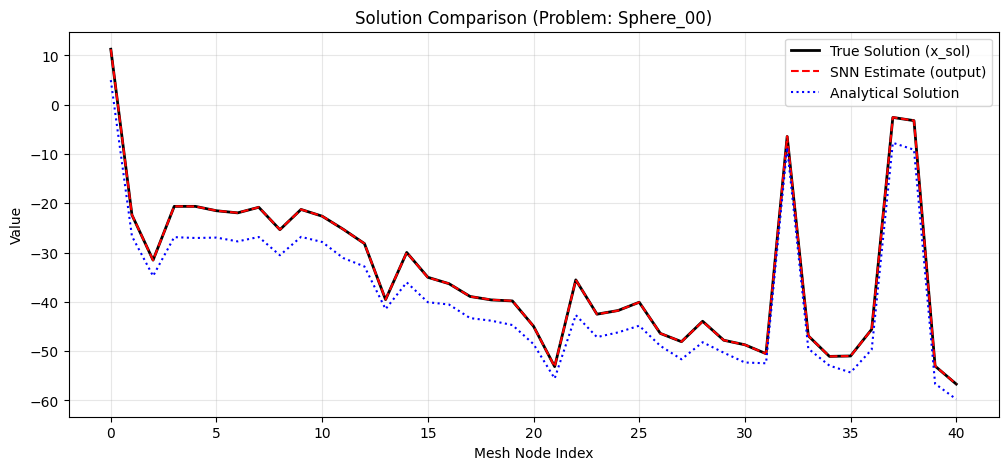

In [7]:

x_estimated = output[:, -1]


error_norm = np.linalg.norm(x_estimated - x_sol)
true_norm = np.linalg.norm(x_sol)
rel_error = error_norm / true_norm

print(f"========================================")
print(f"Final Relative Error: {rel_error:.4e}")
print(f"========================================")


plt.figure(figsize=(12, 5))


plt.plot(x_sol, 'k-', linewidth=2, label='True Solution (x_sol)')
plt.plot(x_estimated, 'r--', linewidth=1.5, label='SNN Estimate (output)')
plt.plot(x_analytical, 'b:', linewidth=1.5, label='Analytical Solution')
plt.title(f'Solution Comparison (Problem: {problem_name})')
plt.xlabel('Mesh Node Index')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)


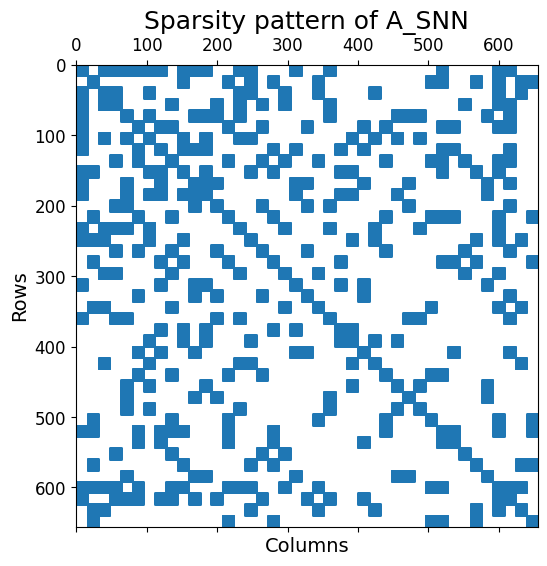

In [8]:
font_size=14
plt.figure(figsize=(6, 6))
plt.spy(GTAG, markersize=1)
plt.title("Sparsity pattern of A_SNN", fontsize=font_size + 4)
plt.xlabel("Columns", fontsize=font_size)
plt.ylabel("Rows", fontsize=font_size)
plt.xticks(fontsize=font_size - 2)
plt.yticks(fontsize=font_size - 2)
plt.show()

### Part 2: converter to spinnaker format

In [9]:

import brian2 #emulator for neuromorphic hardware
from spinnaker2 import snn, brian2_sim

In [10]:
import numpy as np
import scipy.sparse as sp

from spinnaker2 import snn, brian2_sim


nmesh = A.shape[0]


npm = 16                      # neurons per mesh point
gamma = 2.0 ** -6
lambda_d = 8.0
lambda_v = 16.0
k_p = 4.0
k_i = 16.0

theta = 0.5 * (gamma ** 2)

timesteps = 10000
sys_tick_in_s = 1e-3

###############################################################################
# 3. BUILD CONNECTION LIST (MATRIX → SPIKES)
###############################################################################

row_idx, col_idx = sp.csr_matrix(A).nonzero()
conns = []

for r, c in zip(row_idx, col_idx):
    weight = -A[r, c] * (gamma ** 2)

    for k in range(npm):
        conns.append([
            int(c * npm + k),   # pre neuron
            int(r * npm + k),   # post neuron
            float(weight),
            0                   # delay
        ])

# IMPORTANT:
# Emulator does NOT solve the system.
# These parameters are only passed through to validate packing & mapping.
gb_per_mesh = b * gamma
gb_expanded = np.repeat(gb_per_mesh, npm)

neuron_params = {
    "gb": gb_expanded,
    "threshold": theta,
    "lambda_d": lambda_d,
    "lambda_v": lambda_v,
    "k_p": k_p,
    "k_i": k_i,

    # Required by lif backend (ignored by hardware NeuroFEM)
    "v_reset": 0.0,
    "v_rest": 0.0,
    "tau_m": 1.0,
    "tau_syn_E": 1.0,
    "tau_syn_I": 1.0,
}


nb_neurons = nmesh * npm

# >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>
# THIS IS THE ONLY LINE THAT CHANGES ON REAL HARDWARE
neuron_model = "lif"              # emulator
# neuron_model = "neurofem_2048"  # hardware
# <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<

pop = snn.Population(
    size=nb_neurons,
    neuron_model=neuron_model,
    params=neuron_params,
    name="pop-neurofem",
    record=["spikes"]
)

pop.set_max_atoms_per_core(256)

proj = snn.Projection(
    pre=pop,
    post=pop,
    connections=conns,
    name="proj-neurofem"
)

net = snn.Network("net-neurofem")
net.add(pop, proj)

print("Running Brian2 emulation...")

hw = brian2_sim.Brian2Backend()
hw.run(
    net,
    time_steps=timesteps,
    sys_tick_in_s=sys_tick_in_s
)

spikes = pop.get_spikes()

total_spikes = sum(len(v) for v in spikes.values())

print("\n--- EMULATOR VALIDATION ---")
print(f"Neurons:        {nb_neurons}")
print(f"Connections:    {len(conns)}")
print(f"Total spikes:   {total_spikes}")
print(f"Active neurons: {len(spikes)}")

if total_spikes == 0:
    print("WARNING: No spikes detected (check scaling if unexpected)")
else:
    print("SUCCESS: Network is active and executable")


###############################################################################
# 8. DECODING AND VERIFICATION
###############################################################################
print("\n--- SOLUTION VERIFICATION ---")

# A. Calculate Ground Truth (Standard Numerical Solution)
# -------------------------------------------------------
try:
    x_true = sp.linalg.spsolve(A, b)
    print(f"Ground Truth (x_true): {np.round(x_true, 4)}")
except np.linalg.LinAlgError:
    print("Error: Matrix A is singular or ill-conditioned.")
    x_true = np.zeros(nmesh)

# B. Decode Spikes (Reconstruct x from SNN)
# -------------------------------------------------------
# In NeuroFEM, x ~ FiringRate.
# We sum the spikes of all 'npm' neurons belonging to one mesh point.
x_est_raw = np.zeros(nmesh)

for i in range(nmesh):
    # Aggregate spikes for all neurons mapping to mesh point i
    total_count = 0
    for k in range(npm):
        neuron_id = i * npm + k
        if neuron_id in spikes:
            total_count += len(spikes[neuron_id])
    
    # Store the raw spike count as the estimate
    x_est_raw[i] = total_count

# C. Scaling and Comparison
# -------------------------------------------------------
# Because the emulator (LIF) and hardware have different scaling constants
# (gamma, timesteps, etc.), we often compare the normalized vectors
# to check if the 'shape' of the solution is correct.


# Avoid divide by zero
if np.max(x_est_raw) > 0:

    x_est_norm = x_est_raw / np.linalg.norm(x_est_raw)
    x_true_norm = x_true / np.linalg.norm(x_true)
    # Normalize both vectors to unit length for shape comparison
    
    mse = np.mean((x_true_norm - x_est_norm) ** 2)
    print(f"SNN Raw Counts:        {x_est_raw.astype(int)}")
    print(f"x_true_norm:    {np.round(x_true_norm, 4)}")
    print(f"SNN x_norm:      {np.round(x_est_norm, 4)}")
    print(f"Normalized MSE:  {mse:.4f}")
    
    # Check absolute magnitude (requires knowledge of theoretical scaling factor)
    # Theoretical Rate ~ (x * gamma) / (timestep)
    # This is often tricky in emulation due to model mismatches.
else:
    print("SNN output is all zeros. Cannot compare.")


Running Brian2 emulation...
Starting simulation at t=0. s for a duration of 10. s
10. s (100%) simulated in < 1s
finished run
getting spikes from pop-neurofem

--- EMULATOR VALIDATION ---
Neurons:        656
Connections:    6448
Total spikes:   0
Active neurons: 656

--- SOLUTION VERIFICATION ---
Ground Truth (x_true): [ 11.267  -22.36   -31.5274 -20.6239 -20.6205 -21.5104 -21.9418 -20.806
 -25.3551 -21.2465 -22.6144 -25.274  -28.1735 -39.5439 -29.976  -35.0127
 -36.3103 -38.9073 -39.6052 -39.816  -44.947  -53.1407 -35.5367 -42.4982
 -41.7566 -40.0756 -46.4049 -48.0787 -43.9354 -47.7848 -48.7102 -50.5144
  -6.4407 -46.8932 -51.0655 -50.9801 -45.5669  -2.575   -3.2253 -53.0406
 -56.6838]
SNN output is all zeros. Cannot compare.


In [11]:
from spinnaker2 import brian2_sim
import inspect

print("--- Available attributes in brian2_sim ---")
# List all names in the module
print(dir(brian2_sim))

print("\n--- Classes in brian2_sim ---")
# Print only the classes (one of these is the hardware emulator)
for name, obj in inspect.getmembers(brian2_sim):
    if inspect.isclass(obj):
        print(f"Class: {name}")

--- Available attributes in brian2_sim ---
['Brian2Backend', 'Hz', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'apply_neuron_param_to_lif_curr_exp_neuron_group', 'apply_neuron_param_to_lif_neuron_group', 'brian2', 'compute_decay', 'compute_tau', 'copy', 'eqs_lif', 'eqs_lif_curr_exp', 'lif_reset', 'ms', 'np', 'on_pre_action', 'quantize_clip', 'second', 'seed', 'snn', 'spinnaker2']

--- Classes in brian2_sim ---
Class: Brian2Backend


In [12]:
x_true_norm = x_true / np.linalg.norm(x_true)
x_snn_norm = x_est_raw / np.linalg.norm(x_est_raw)

mse_norm = np.mean((x_true_norm - x_snn_norm)**2)
print("Normalized MSE:", mse_norm)

WARNING    /tmp/ipykernel_10606/1567344509.py:2: RuntimeWarning: invalid value encountered in divide
  x_snn_norm = x_est_raw / np.linalg.norm(x_est_raw)
 [py.warnings]


Normalized MSE: nan


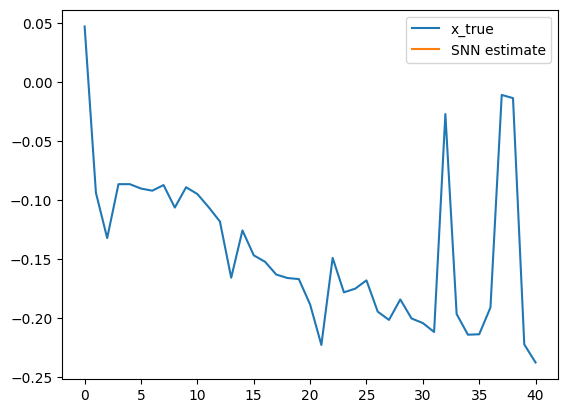

In [13]:
import matplotlib.pyplot as plt
plt.plot(x_true_norm, label="x_true")
plt.plot(x_snn_norm, label="SNN estimate")
plt.legend()
plt.show()